# 🔍 Dual-Stream Model Prediction Visualization

## Objective
Visualize the Dual-Stream model's predictions on actual surgical videos to verify:
1. Does it predict the **major** bleeding events (biggest peaks)?
2. How far in advance does it predict?
3. What do the actual frames look like when it predicts bleeding?

## What This Notebook Does
For 3 random test videos:
1. **Show ground truth**: All peaks + major bleeding events (above threshold)
2. **Show predictions**: Where the model predicts bleeding
3. **Frame-by-frame analysis**: Actual surgical images at prediction points
4. **Verify**: Did it catch the biggest peaks?

Let's investigate! 🔬

In [1]:
# Cell 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import json
import cv2
from PIL import Image

import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

print("✅ Imports complete")

✅ Imports complete


In [2]:
# Cell 2: Configuration
class Config:
    # Paths
    ALIGNED_DIR = Path("cleaned_aligned_dataset/aligned_dataset")
    FRAMES_DIR = Path("/raid/bsmse6/data/CholecT45_extracted/CholecT45/data")  # Original frames
    MASKS_DIR = Path("all_videos_blood_segmentation/masks")  # Blood masks
    MODEL_PATH = Path("best_model_dual.pth")
    OUTPUT_DIR = Path("prediction_visualizations")
    
    # From training
    THRESHOLD = 10602.45
    WINDOW_SIZE = 6
    PREDICTION_HORIZON = 5
    
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create output directory
Config.OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

print(f"Configuration loaded")
print(f"Device: {Config.DEVICE}")
print(f"Threshold: {Config.THRESHOLD:.1f} pixels")

Configuration loaded
Device: cuda
Threshold: 10602.5 pixels


In [4]:
# Cell 3: Load Dual-Stream Model Architecture
#
# IMPORTANT: Architecture names must EXACTLY match the saved model!
# Your saved model uses 'inst_stream' not 'instrument_stream'

class DualStreamMLP(nn.Module):
    """Dual-stream MLP: Separate pathways for instruments and blood"""
    def __init__(self):
        super().__init__()
        
        # Instrument stream (36 features: 6 frames × 6 instruments)
        # CRITICAL: Using 'inst_stream' to match your saved model
        self.inst_stream = nn.Sequential(
            nn.Linear(36, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        
        # Blood stream (6 features: 6 frames × 1 blood area)
        self.blood_stream = nn.Sequential(
            nn.Linear(6, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 8),
            nn.ReLU()
        )
        
        # Merged pathway (32 + 8 = 40)
        self.merged = nn.Sequential(
            nn.Linear(40, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)
        )
    
    def forward(self, x):
        batch_size = x.shape[0]
        
        # Reshape to (batch, 6 frames, 7 features)
        x_reshaped = x.view(batch_size, 6, 7)
        
        # Separate instruments and blood
        instruments = x_reshaped[:, :, :6].contiguous().view(batch_size, -1)  # (batch, 36)
        blood = x_reshaped[:, :, 6].contiguous().view(batch_size, -1)  # (batch, 6)
        
        # Process separately - CHANGED: inst_stream instead of instrument_stream
        inst_features = self.inst_stream(instruments)
        blood_features = self.blood_stream(blood)
        
        # Merge and classify
        merged = torch.cat([inst_features, blood_features], dim=1)
        output = self.merged(merged)
        
        return output

# Load trained model
model = DualStreamMLP().to(Config.DEVICE)
model.load_state_dict(torch.load(Config.MODEL_PATH))
model.eval()

print("✅ Dual-Stream model loaded")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")

✅ Dual-Stream model loaded
   Parameters: 18,746


In [6]:
# Cell 4: Load or Create Test Videos Split
#
# If split_info.json exists, use it
# Otherwise, manually select test videos or create split

import os

# Try to load existing split
if os.path.exists('split_info.json'):
    print("Loading existing split...")
    with open('split_info.json', 'r') as f:
        split_info = json.load(f)
    test_videos = split_info['test_videos']
    print(f"✅ Loaded split from file")
else:
    print("⚠️  split_info.json not found!")
    print("Creating test split from available videos...")
    
    # Get all available videos
    all_videos = []
    for file in sorted(Config.ALIGNED_DIR.glob("*_aligned.npz")):
        video_id = file.stem.replace('_aligned', '')
        all_videos.append(video_id)
    
    print(f"Found {len(all_videos)} videos total")
    
    # Use last 15% as test (similar to training split)
    num_test = max(3, int(len(all_videos) * 0.15))
    
    # Random split (reproducible with seed)
    np.random.seed(42)
    shuffled = np.random.permutation(all_videos)
    
    test_videos = shuffled[-num_test:].tolist()
    train_val_videos = shuffled[:-num_test].tolist()
    
    # Create split_info
    split_info = {
        'test_videos': test_videos,
        'train_val_videos': train_val_videos,
        'total_videos': len(all_videos),
        'test_size': len(test_videos)
    }
    
    # Save for future use
    with open('split_info.json', 'w') as f:
        json.dump(split_info, f, indent=2)
    
    print(f"✅ Created new split")
    print(f"   Test videos: {len(test_videos)}")

print(f"\nTotal test videos: {len(test_videos)}")
print(f"Test videos: {test_videos}")

# Randomly select 3 test videos for visualization
np.random.seed(42)
selected_videos = np.random.choice(test_videos, size=min(3, len(test_videos)), replace=False)

print(f"\n✅ Selected videos for visualization: {list(selected_videos)}")

⚠️  split_info.json not found!
Creating test split from available videos...
Found 45 videos total
✅ Created new split
   Test videos: 6

Total test videos: 6
Test videos: ['VID80', 'VID35', 'VID12', 'VID25', 'VID50', 'VID70']

✅ Selected videos for visualization: [np.str_('VID80'), np.str_('VID35'), np.str_('VID70')]


In [7]:
# Cell 5: Function to Process Video and Get Predictions
#
# This function:
# 1. Loads video data
# 2. Creates temporal features (same as training)
# 3. Runs the model to get predictions
# 4. Returns everything needed for visualization

def process_video_with_predictions(video_id, model, scaler, threshold):
    """
    Process a video and get model predictions
    
    Returns:
        data: Video data (blood areas, peaks, etc.)
        predictions: Model predictions for each frame
        probabilities: Prediction probabilities
        major_peaks: Ground truth major bleeding events
    """
    # Load aligned data
    aligned_file = Config.ALIGNED_DIR / f"{video_id}_aligned.npz"
    data = np.load(aligned_file, allow_pickle=True)
    
    instruments = data['instrument_labels']
    blood = data['smoothed_blood_areas']
    all_peaks = data['peaks']
    frame_indices = data['frame_indices']
    
    # Filter to major peaks
    major_peaks = [p for p in all_peaks if blood[p] >= threshold]
    major_peaks = np.array(major_peaks)
    
    # Create temporal features (same as training)
    per_frame = np.column_stack([instruments, blood])
    
    features_list = []
    valid_indices = []
    
    for i in range(Config.WINDOW_SIZE - 1, len(per_frame)):
        window = per_frame[i - Config.WINDOW_SIZE + 1:i + 1]
        features_list.append(window.flatten())
        valid_indices.append(i)
    
    features = np.array(features_list)
    valid_indices = np.array(valid_indices)
    
    # Scale features (using scaler from training)
    features_scaled = scaler.transform(features)
    
    # Get predictions
    model.eval()
    with torch.no_grad():
        features_tensor = torch.FloatTensor(features_scaled).to(Config.DEVICE)
        outputs = model(features_tensor)
        probs = torch.softmax(outputs, dim=1)
        
        # Probability of bleeding (class 1)
        bleeding_probs = probs[:, 1].cpu().numpy()
        
        # Predictions (threshold = 0.5)
        predictions = (bleeding_probs > 0.5).astype(int)
    
    return {
        'video_id': video_id,
        'instruments': instruments,
        'blood_areas': blood,
        'all_peaks': all_peaks,
        'major_peaks': major_peaks,
        'frame_indices': frame_indices,
        'valid_indices': valid_indices,
        'predictions': predictions,
        'probabilities': bleeding_probs
    }

print("✅ Video processing function defined")

✅ Video processing function defined


In [8]:
# Cell 6: Load Scaler from Training
#
# We need the same scaler used during training to properly normalize features

import pickle

# Try to load saved scaler
try:
    with open('scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)
    print("✅ Loaded scaler from training")
except:
    print("⚠️  Scaler not found. Creating new one...")
    print("   (Note: This should match the training scaler)")
    
    # If scaler wasn't saved, we need to recreate it
    # This is a fallback - ideally use the saved scaler
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    
    # Fit on all training data (quick approximation)
    all_features = []
    for file in Config.ALIGNED_DIR.glob("*_aligned.npz"):
        data = np.load(file, allow_pickle=True)
        instruments = data['instrument_labels']
        blood = data['smoothed_blood_areas']
        per_frame = np.column_stack([instruments, blood])
        
        for i in range(5, len(per_frame)):
            window = per_frame[i-5:i+1].flatten()
            all_features.append(window)
    
    scaler.fit(np.array(all_features))
    print("✅ Created scaler from data")

⚠️  Scaler not found. Creating new one...
   (Note: This should match the training scaler)
✅ Created scaler from data


In [9]:
# Cell 7: Process Selected Videos
#
# Run the model on each selected video

print("Processing videos and getting predictions...\n")

video_results = {}

for video_id in tqdm(selected_videos, desc="Processing"):
    result = process_video_with_predictions(
        video_id,
        model,
        scaler,
        Config.THRESHOLD
    )
    video_results[video_id] = result
    
    print(f"\n{video_id}:")
    print(f"  Total frames: {len(result['blood_areas']):,}")
    print(f"  All peaks: {len(result['all_peaks'])}")
    print(f"  Major peaks: {len(result['major_peaks'])}")
    print(f"  Predictions made: {len(result['predictions']):,}")
    print(f"  Predicted bleeding: {np.sum(result['predictions'])} times")

print("\n✅ All videos processed")

Processing videos and getting predictions...



Processing: 100%|██████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 18.49it/s]


VID80:
  Total frames: 1,725
  All peaks: 28
  Major peaks: 20
  Predictions made: 1,720
  Predicted bleeding: 324 times

VID35:
  Total frames: 2,107
  All peaks: 20
  Major peaks: 6
  Predictions made: 2,102
  Predicted bleeding: 111 times

VID70:
  Total frames: 1,195
  All peaks: 18
  Major peaks: 1
  Predictions made: 1,190
  Predicted bleeding: 26 times

✅ All videos processed


In [10]:
# Cell 8: Visualization Function - Timeline with Predictions
#
# Create comprehensive timeline showing:
# 1. Blood area curve
# 2. All peaks (gray circles)
# 3. Major peaks (red stars) - ground truth
# 4. Model predictions (yellow highlights)

def visualize_predictions_timeline(result):
    """
    Create timeline visualization comparing ground truth and predictions
    """
    video_id = result['video_id']
    blood = result['blood_areas']
    all_peaks = result['all_peaks']
    major_peaks = result['major_peaks']
    frame_indices = result['frame_indices']
    valid_indices = result['valid_indices']
    predictions = result['predictions']
    probabilities = result['probabilities']
    
    fig, axes = plt.subplots(2, 1, figsize=(24, 10), sharex=True)
    
    # TOP PLOT: Ground Truth
    ax1 = axes[0]
    
    # Blood area
    ax1.plot(frame_indices, blood, color='darkred', linewidth=2, label='Blood Area')
    ax1.fill_between(frame_indices, 0, blood, alpha=0.2, color='red')
    
    # Threshold line
    ax1.axhline(Config.THRESHOLD, color='orange', linestyle='--', linewidth=2,
               label=f'Major Bleeding Threshold ({Config.THRESHOLD:.0f}px)', alpha=0.7)
    
    # All peaks (minor)
    minor_peaks = [p for p in all_peaks if blood[p] < Config.THRESHOLD]
    if len(minor_peaks) > 0:
        ax1.scatter(minor_peaks, blood[minor_peaks],
                   color='gray', s=80, marker='o', alpha=0.5, zorder=4,
                   label=f'Minor Peaks ({len(minor_peaks)})')
    
    # Major peaks (ground truth)
    if len(major_peaks) > 0:
        ax1.scatter(major_peaks, blood[major_peaks],
                   color='red', s=300, marker='*', zorder=5,
                   edgecolors='black', linewidths=2,
                   label=f'MAJOR BLEEDING EVENTS ({len(major_peaks)}) - GROUND TRUTH')
    
    ax1.set_ylabel('Blood Area (pixels)', fontsize=14, fontweight='bold')
    ax1.set_title(f'{video_id.upper()} - GROUND TRUTH: Major Bleeding Events',
                 fontsize=16, fontweight='bold', color='darkred')
    ax1.legend(loc='upper right', fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # BOTTOM PLOT: Model Predictions
    ax2 = axes[1]
    
    # Blood area (same)
    ax2.plot(frame_indices, blood, color='darkred', linewidth=2, alpha=0.5)
    ax2.fill_between(frame_indices, 0, blood, alpha=0.1, color='red')
    
    # Highlight where model predicts bleeding
    predicted_frames = valid_indices[predictions == 1]
    if len(predicted_frames) > 0:
        # Create yellow highlights
        for frame in predicted_frames:
            ax2.axvspan(frame - 0.5, frame + 0.5, alpha=0.3, color='yellow', zorder=1)
    
    # Plot prediction probability
    ax2_twin = ax2.twinx()
    ax2_twin.plot(valid_indices, probabilities, color='blue', linewidth=2, alpha=0.7,
                 label='P(Bleeding) - Model Confidence')
    ax2_twin.axhline(0.5, color='blue', linestyle='--', linewidth=1, alpha=0.5,
                    label='Decision Threshold (0.5)')
    ax2_twin.set_ylabel('Prediction Probability', fontsize=12, fontweight='bold', color='blue')
    ax2_twin.tick_params(axis='y', labelcolor='blue')
    ax2_twin.set_ylim(-0.05, 1.05)
    ax2_twin.legend(loc='upper left', fontsize=10)
    
    # Mark major peaks for reference
    if len(major_peaks) > 0:
        ax2.scatter(major_peaks, blood[major_peaks],
                   color='red', s=200, marker='*', zorder=5,
                   edgecolors='black', linewidths=1.5, alpha=0.6,
                   label='Major Peaks (Reference)')
    
    ax2.set_xlabel('Frame Index', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Blood Area (pixels)', fontsize=14, fontweight='bold')
    ax2.set_title(f'{video_id.upper()} - MODEL PREDICTIONS (Yellow = Predicted Bleeding)',
                 fontsize=16, fontweight='bold', color='darkblue')
    ax2.legend(loc='upper right', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save
    output_file = Config.OUTPUT_DIR / f"{video_id}_prediction_timeline.png"
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Saved: {output_file}")
    
    return predicted_frames

print("✅ Visualization function defined")

✅ Visualization function defined


Generating timeline visualizations...


Processing VID80...


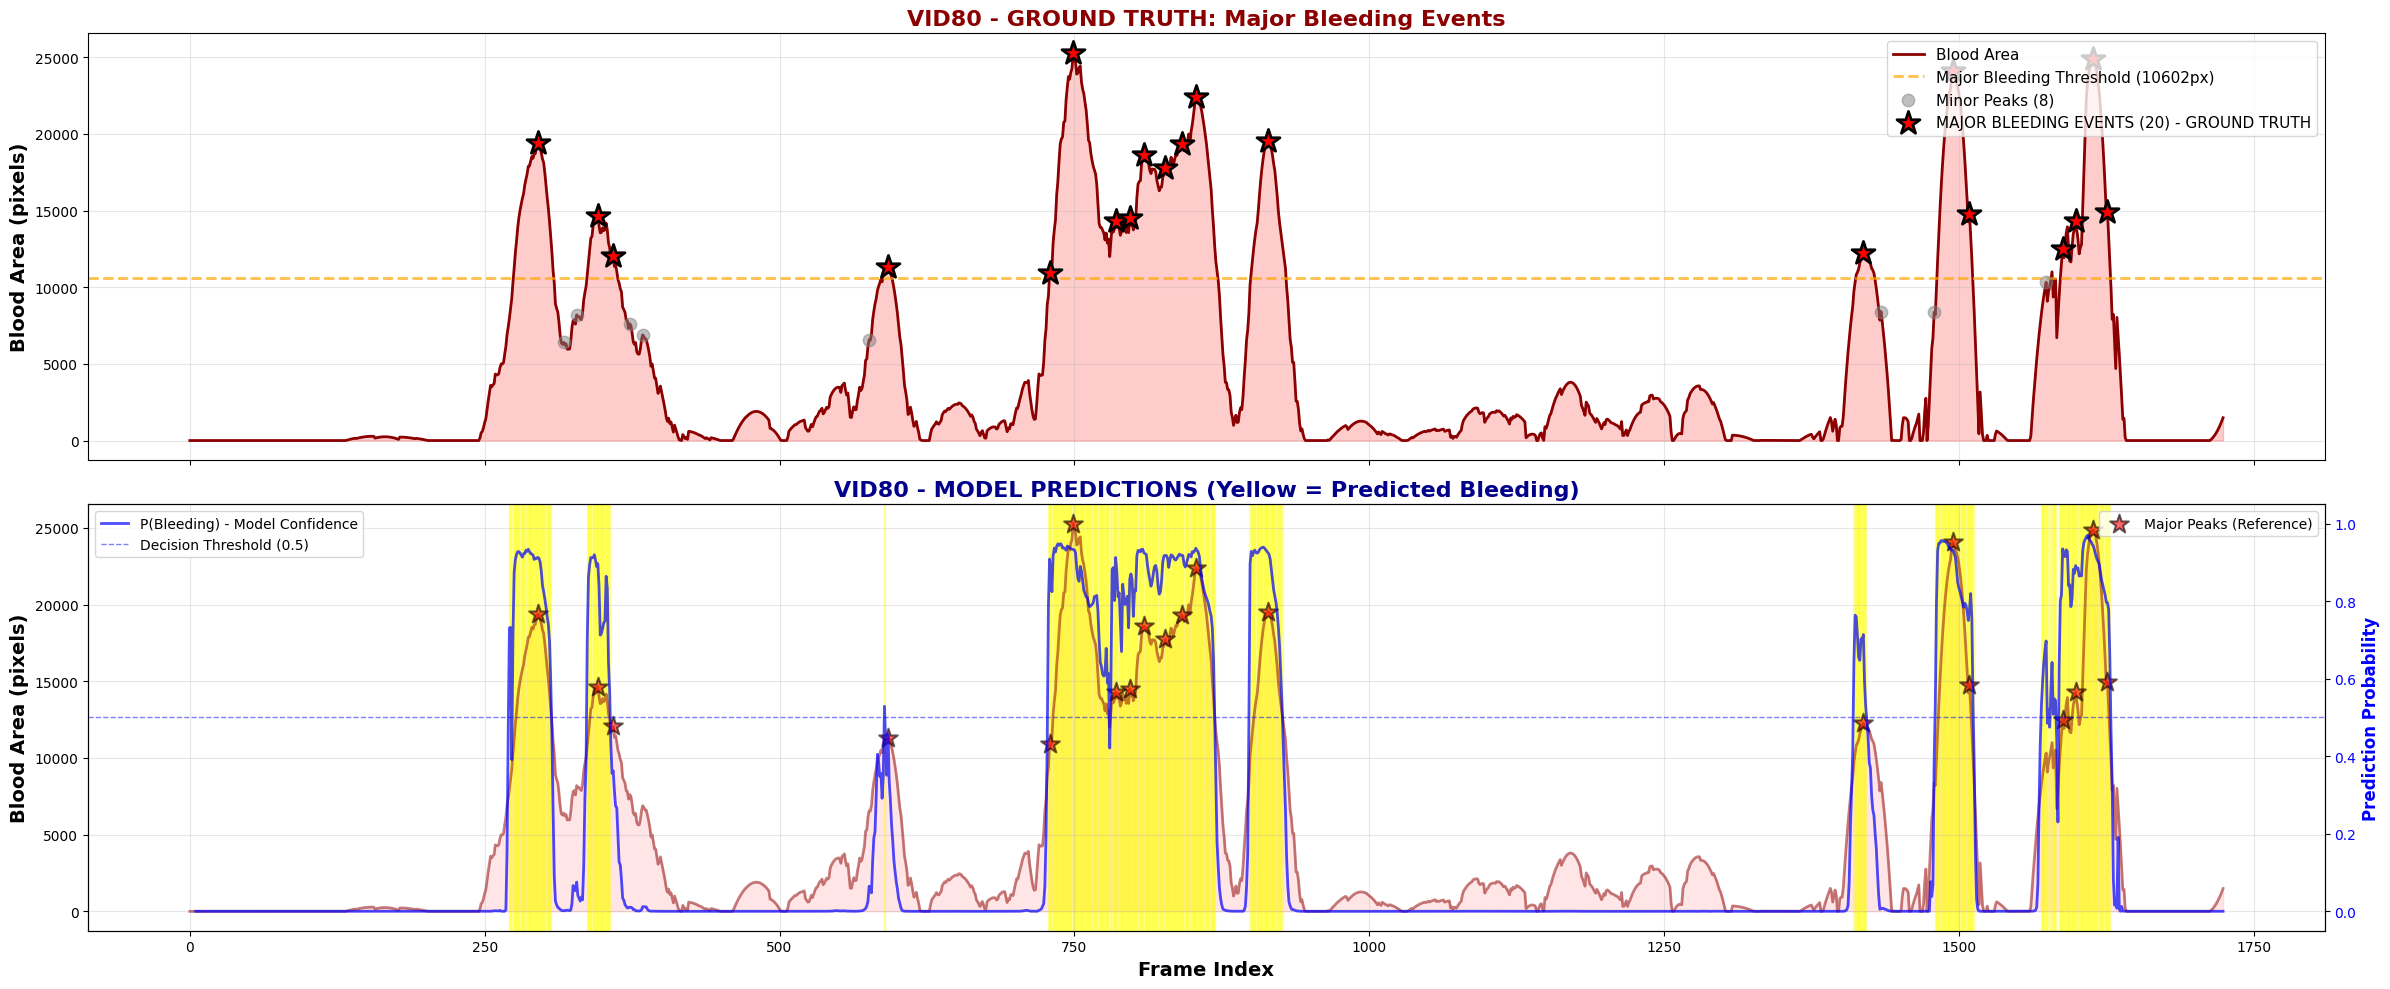

✅ Saved: prediction_visualizations/VID80_prediction_timeline.png
   Predicted bleeding at 324 frames

Processing VID35...


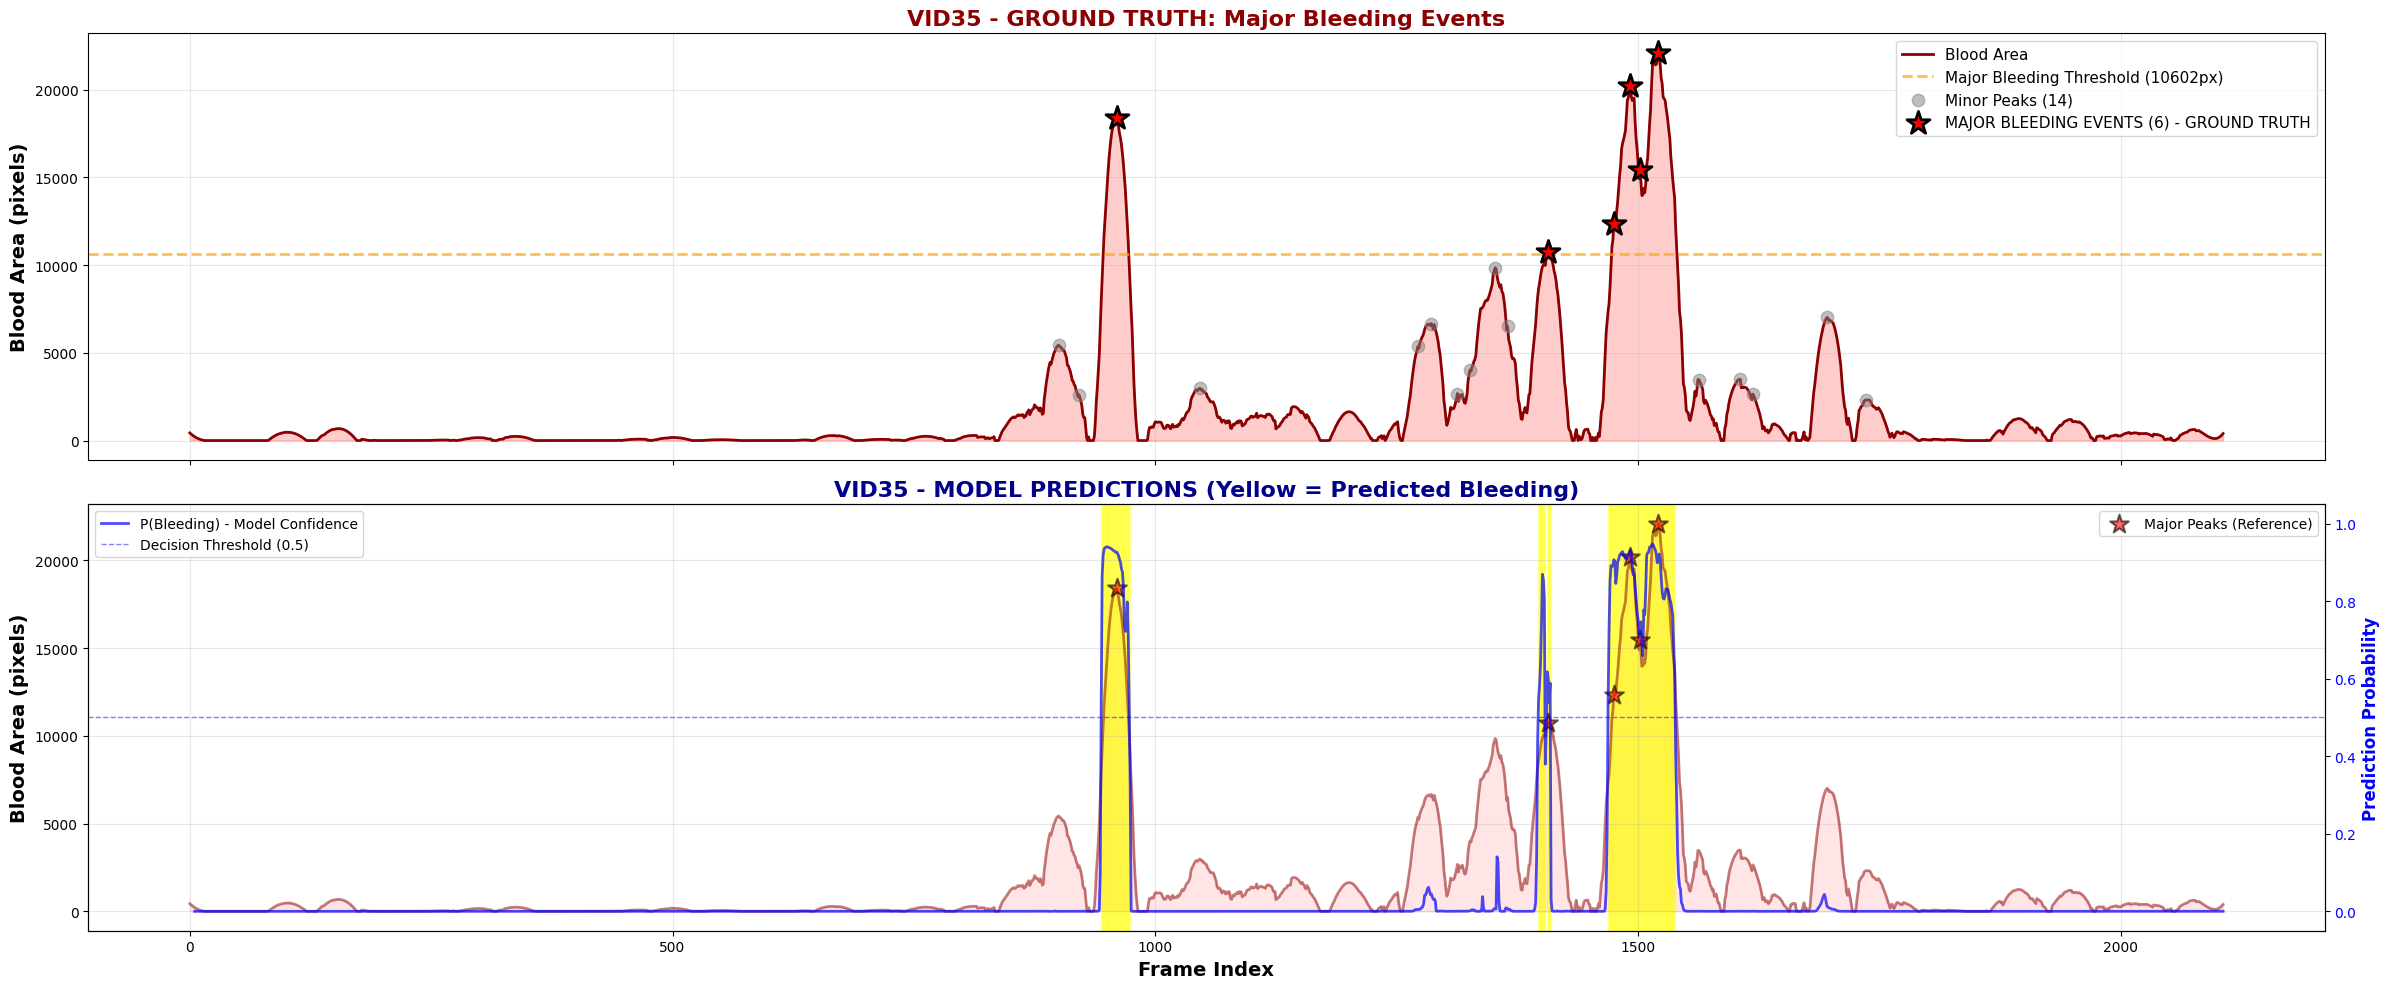

✅ Saved: prediction_visualizations/VID35_prediction_timeline.png
   Predicted bleeding at 111 frames

Processing VID70...


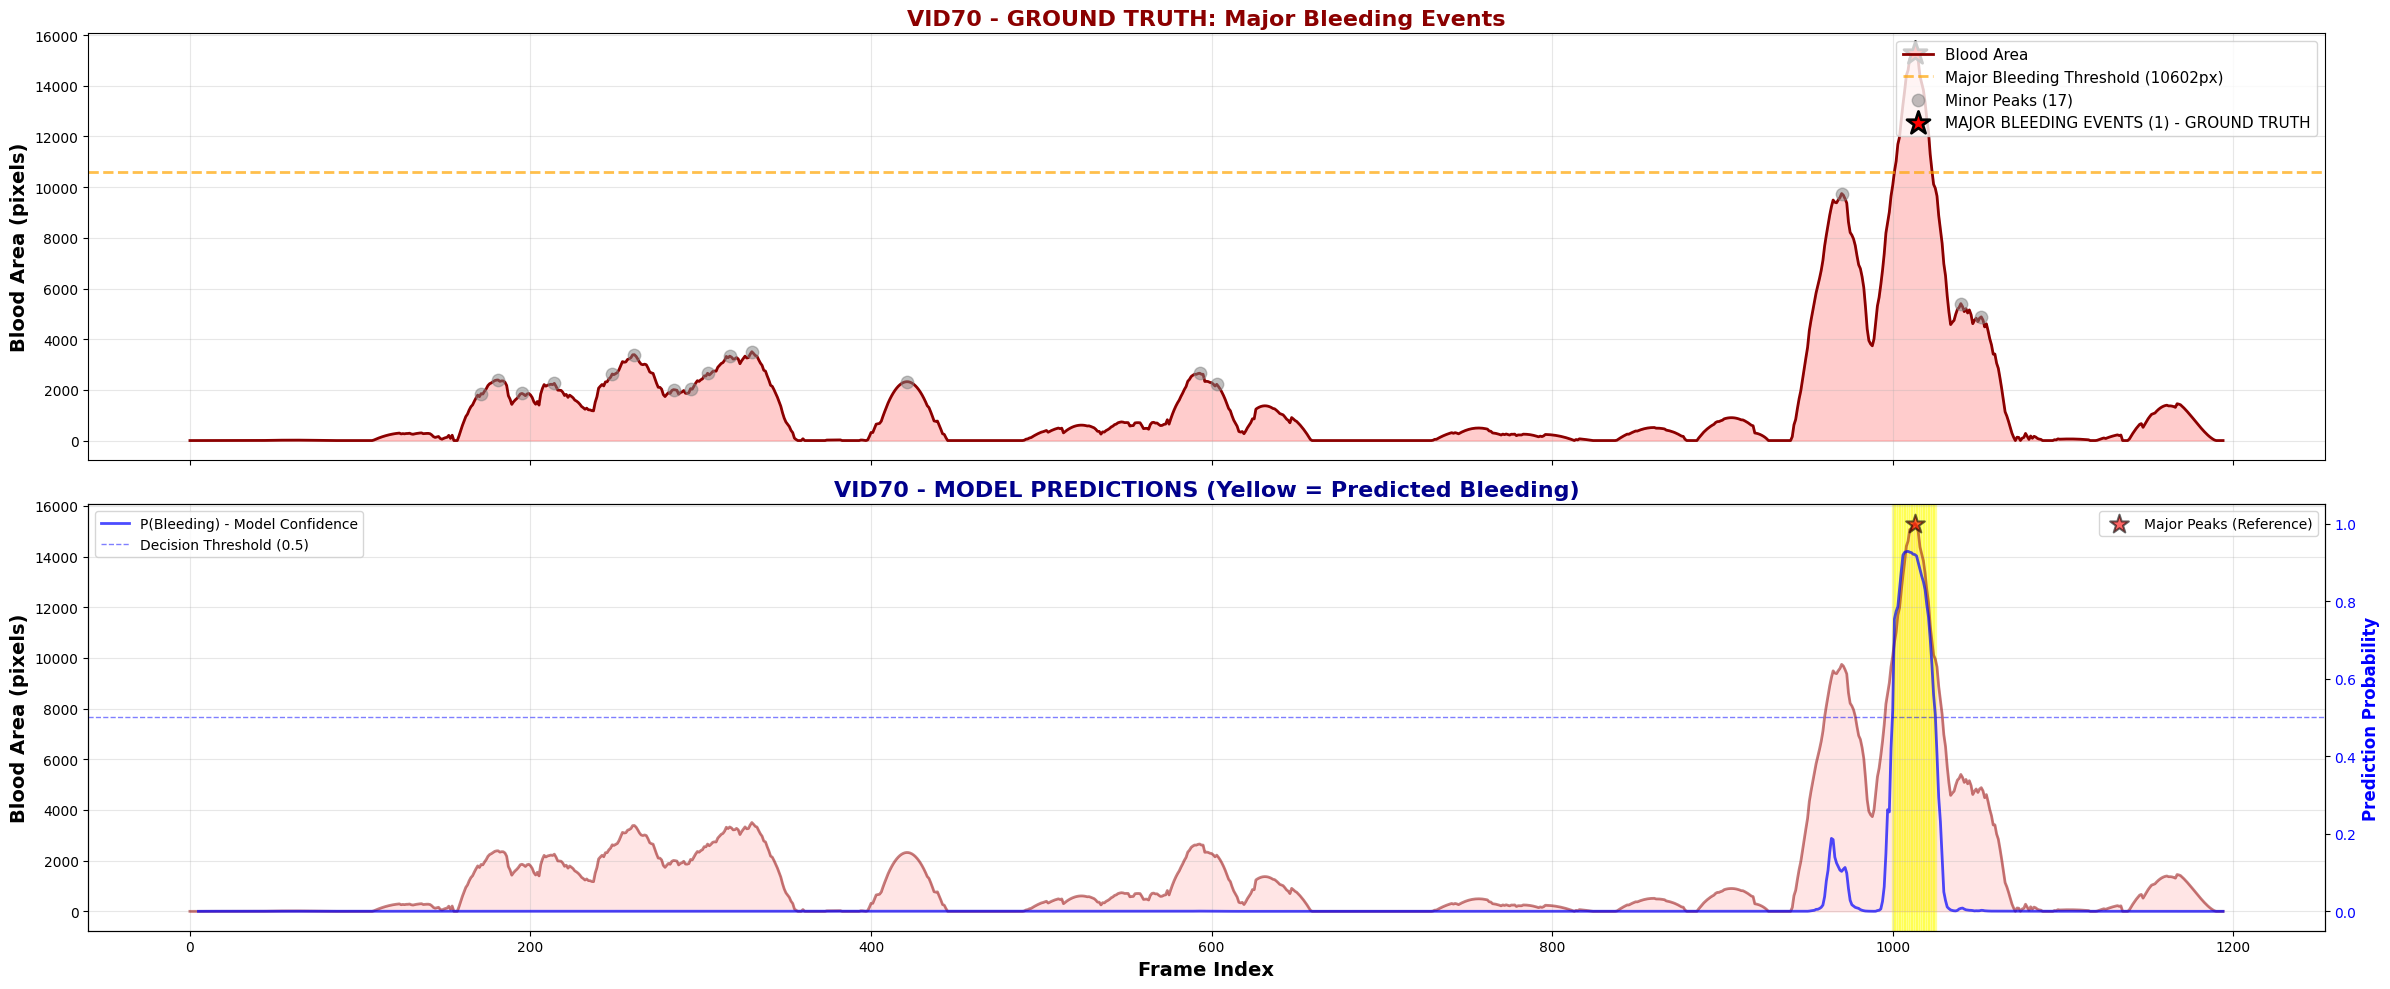

✅ Saved: prediction_visualizations/VID70_prediction_timeline.png
   Predicted bleeding at 26 frames

✅ All timeline visualizations complete


In [11]:
# Cell 9: Generate Timeline Visualizations
#
# Create timeline plots for all 3 selected videos

print("Generating timeline visualizations...\n")

all_predicted_frames = {}

for video_id in selected_videos:
    print(f"\nProcessing {video_id}...")
    result = video_results[video_id]
    predicted_frames = visualize_predictions_timeline(result)
    all_predicted_frames[video_id] = predicted_frames
    print(f"   Predicted bleeding at {len(predicted_frames)} frames")

print("\n✅ All timeline visualizations complete")

In [ ]:
# Cell 10: Analysis - Did Model Catch Major Peaks?
#
# For each major peak, check if model predicted bleeding
# in the 5 frames leading up to it

print("\n" + "="*80)
print("ANALYSIS: Did Model Predict Major Bleeding Events?")
print("="*80)

for video_id in selected_videos:
    result = video_results[video_id]
    major_peaks = result['major_peaks']
    valid_indices = result['valid_indices']
    predictions = result['predictions']
    blood = result['blood_areas']
    
    print(f"\n{video_id.upper()}:")
    print(f"  Major bleeding events: {len(major_peaks)}")
    
    if len(major_peaks) == 0:
        print("  No major bleeding events in this video")
        continue
    
    # For each major peak, check if predicted
    caught = 0
    
    for peak in major_peaks:
        peak_blood = blood[peak]
        
        # Check 5 frames before peak
        warning_frames = list(range(peak - Config.PREDICTION_HORIZON, peak))
        
        # Which of these frames have predictions?
        predicted_in_warning = []
        for frame in warning_frames:
            if frame in valid_indices:
                idx = np.where(valid_indices == frame)[0][0]
                if predictions[idx] == 1:
                    predicted_in_warning.append(frame)
        
        if len(predicted_in_warning) > 0:
            caught += 1
            status = "✅ CAUGHT"
        else:
            status = "❌ MISSED"
        
        print(f"\n  Peak at frame {peak} (blood: {peak_blood:.0f}px): {status}")
        if len(predicted_in_warning) > 0:
            earliest_warning = min(predicted_in_warning)
            advance_notice = peak - earliest_warning
            print(f"    → Predicted at frames: {predicted_in_warning}")
            print(f"    → Earliest warning: {advance_notice} frames ahead")
    
    print(f"\n  Summary: Caught {caught}/{len(major_peaks)} major bleeding events ({100*caught/len(major_peaks):.1f}%)")

print("\n" + "="*80)

In [ ]:
# Cell 11: Function to Load and Display Frames
#
# Load actual surgical frames and blood masks for visualization

def load_frame_and_mask(video_id, frame_number):
    """
    Load original frame and blood mask
    
    Returns:
        frame: RGB image
        mask: Blood segmentation mask
    """
    # Frame path
    frame_path = Config.FRAMES_DIR / video_id / f"{frame_number:06d}.png"
    
    # Mask path
    mask_path = Config.MASKS_DIR / video_id / f"{frame_number:06d}.png"
    
    # Load frame
    if frame_path.exists():
        frame = cv2.imread(str(frame_path))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    else:
        frame = None
    
    # Load mask
    if mask_path.exists():
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    else:
        mask = None
    
    return frame, mask

def visualize_prediction_with_frames(video_id, peak_frame, result):
    """
    Show frames leading up to a major peak with model predictions
    """
    # Get frames: 5 before peak + peak itself
    frames_to_show = list(range(peak_frame - 5, peak_frame + 1))
    
    # Get predictions for these frames
    valid_indices = result['valid_indices']
    predictions = result['predictions']
    probabilities = result['probabilities']
    blood = result['blood_areas']
    
    fig, axes = plt.subplots(2, 6, figsize=(24, 8))
    
    for i, frame_num in enumerate(frames_to_show):
        # Load frame and mask
        frame, mask = load_frame_and_mask(video_id, frame_num)
        
        # Get prediction for this frame
        if frame_num in valid_indices:
            idx = np.where(valid_indices == frame_num)[0][0]
            pred = predictions[idx]
            prob = probabilities[idx]
        else:
            pred = -1
            prob = 0
        
        # Top row: Original frame
        ax_top = axes[0, i]
        if frame is not None:
            ax_top.imshow(frame)
        else:
            ax_top.text(0.5, 0.5, 'Frame\nNot Found', ha='center', va='center',
                       fontsize=12, transform=ax_top.transAxes)
        
        # Title
        offset = frame_num - peak_frame
        if offset == 0:
            title = f"PEAK\nFrame {frame_num}"
            color = 'red'
        else:
            title = f"{offset:+d} frames\nFrame {frame_num}"
            color = 'black'
        
        ax_top.set_title(title, fontsize=11, fontweight='bold', color=color)
        ax_top.axis('off')
        
        # Add prediction indicator
        if pred == 1:
            rect = plt.Rectangle((0, 0), frame.shape[1] if frame is not None else 100,
                                frame.shape[0] if frame is not None else 100,
                                fill=False, edgecolor='yellow', linewidth=5)
            ax_top.add_patch(rect)
            ax_top.text(0.5, 0.05, f'PREDICTED\nP={prob:.2f}',
                       ha='center', va='bottom', transform=ax_top.transAxes,
                       fontsize=10, fontweight='bold', color='yellow',
                       bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
        
        # Bottom row: Blood mask
        ax_bottom = axes[1, i]
        if mask is not None:
            ax_bottom.imshow(mask, cmap='Reds', vmin=0, vmax=255)
            blood_area = np.sum(mask > 0)
            ax_bottom.text(0.5, 0.95, f'Blood: {blood_area} px',
                          ha='center', va='top', transform=ax_bottom.transAxes,
                          fontsize=9, color='white',
                          bbox=dict(boxstyle='round', facecolor='darkred', alpha=0.8))
        else:
            ax_bottom.text(0.5, 0.5, 'Mask\nNot Found', ha='center', va='center',
                          fontsize=12, transform=ax_bottom.transAxes)
        
        ax_bottom.axis('off')
    
    # Super title
    peak_blood = blood[peak_frame]
    fig.suptitle(f"{video_id.upper()} - Frames Leading to Major Peak at {peak_frame} (Blood: {peak_blood:.0f}px)\n"
                f"Yellow Border = Model Predicted Bleeding",
                fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    
    # Save
    output_file = Config.OUTPUT_DIR / f"{video_id}_peak_{peak_frame}_frames.png"
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Saved: {output_file}")

print("✅ Frame visualization function defined")

In [ ]:
# Cell 12: Visualize Frames for Biggest Peaks
#
# For each video, show frames for the 2 biggest major peaks

print("\n" + "="*80)
print("FRAME-BY-FRAME VISUALIZATION - BIGGEST PEAKS")
print("="*80)

for video_id in selected_videos:
    result = video_results[video_id]
    major_peaks = result['major_peaks']
    blood = result['blood_areas']
    
    if len(major_peaks) == 0:
        print(f"\n{video_id}: No major peaks to visualize")
        continue
    
    # Get peak heights
    peak_heights = [(peak, blood[peak]) for peak in major_peaks]
    # Sort by height (biggest first)
    peak_heights.sort(key=lambda x: x[1], reverse=True)
    
    # Show top 2 peaks
    num_to_show = min(2, len(peak_heights))
    
    print(f"\n{video_id.upper()}: Showing {num_to_show} biggest peaks")
    
    for i in range(num_to_show):
        peak_frame, peak_blood = peak_heights[i]
        print(f"\n  Peak #{i+1}: Frame {peak_frame}, Blood {peak_blood:.0f}px")
        visualize_prediction_with_frames(video_id, peak_frame, result)

print("\n✅ Frame visualizations complete")

In [ ]:
# Cell 13: Summary Report
#
# Generate a comprehensive summary of findings

print("\n" + "="*80)
print("FINAL SUMMARY - DUAL-STREAM MODEL PERFORMANCE")
print("="*80)

total_major_peaks = 0
total_caught = 0

summary_data = []

for video_id in selected_videos:
    result = video_results[video_id]
    major_peaks = result['major_peaks']
    valid_indices = result['valid_indices']
    predictions = result['predictions']
    blood = result['blood_areas']
    
    if len(major_peaks) == 0:
        continue
    
    caught = 0
    
    for peak in major_peaks:
        # Check if predicted in 5 frames before
        warning_frames = list(range(peak - Config.PREDICTION_HORIZON, peak))
        
        for frame in warning_frames:
            if frame in valid_indices:
                idx = np.where(valid_indices == frame)[0][0]
                if predictions[idx] == 1:
                    caught += 1
                    break
    
    total_major_peaks += len(major_peaks)
    total_caught += caught
    
    summary_data.append({
        'Video': video_id,
        'Major Peaks': len(major_peaks),
        'Caught': caught,
        'Missed': len(major_peaks) - caught,
        'Catch Rate': f"{100*caught/len(major_peaks):.1f}%"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print(f"\n" + "="*80)
print(f"OVERALL PERFORMANCE:")
print(f"  Total major bleeding events: {total_major_peaks}")
print(f"  Successfully predicted: {total_caught}")
print(f"  Missed: {total_major_peaks - total_caught}")
print(f"  Success rate: {100*total_caught/max(total_major_peaks, 1):.1f}%")
print("="*80)

# Save summary
summary_df.to_csv(Config.OUTPUT_DIR / 'prediction_summary.csv', index=False)
print(f"\n✅ Summary saved: {Config.OUTPUT_DIR / 'prediction_summary.csv'}")

print(f"\n📁 All visualizations saved to: {Config.OUTPUT_DIR}")
print(f"\n🎉 Analysis complete!")